# Logistic Regression

### Logistic Regression on data without optimization

Accuracy: 0.4956647398843931
              precision    recall  f1-score   support

         EDM       0.56      0.59      0.57       191
      HipHop       0.53      0.52      0.52       194
       Latin       0.45      0.46      0.45       207
         Pop       0.41      0.46      0.43       233
         R&B       0.43      0.29      0.35       146
         Rap       0.43      0.38      0.40       185
        Rock       0.62      0.69      0.65       228

    accuracy                           0.50      1384
   macro avg       0.49      0.48      0.48      1384
weighted avg       0.49      0.50      0.49      1384



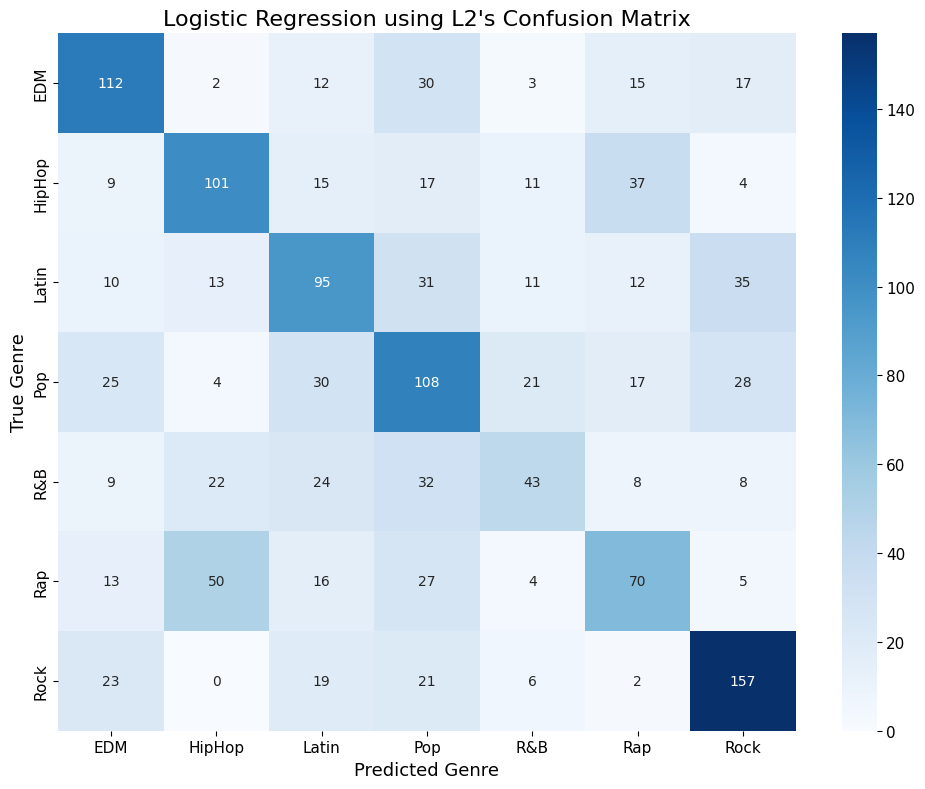

In [25]:
# logistic regression model here
# test out diff hyperparameters, ex. penalty type (L1/L2), regularization
# strength etc. 
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
Y_train = pd.read_csv('../data/Y_train.csv') 
Y_test = pd.read_csv('../data/Y_test.csv')
genre_names = [
    "EDM",
    "HipHop",
    "Latin",
    "Pop",
    "R&B",
    "Rap",
    "Rock"
]
y_train = Y_train.values.ravel()
y_test = Y_test.values.ravel()

# Logistic Regression using L2 regularization
model1 = LogisticRegression(
    l1_ratio=0,
    C=0.3,
    solver='lbfgs',
    max_iter=1000
)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=genre_names
    )
)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=genre_names,
    yticklabels=genre_names
)

plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.title("Logistic Regression using L2's Confusion Matrix")

plt.tight_layout()
plt.show()




Accuracy: 0.4956647398843931
[[112   2  12  30   4  14  17]
 [  9 101  15  17  11  37   4]
 [ 10  13  95  31  11  12  35]
 [ 25   3  30 109  21  17  28]
 [  9  22  25  32  42   8   8]
 [ 13  50  16  27   4  70   5]
 [ 24   0  19  20   6   2 157]]
Accuracy: 0.4956647398843931
              precision    recall  f1-score   support

         EDM       0.55      0.59      0.57       191
      HipHop       0.53      0.52      0.52       194
       Latin       0.45      0.46      0.45       207
         Pop       0.41      0.47      0.44       233
         R&B       0.42      0.29      0.34       146
         Rap       0.44      0.38      0.41       185
        Rock       0.62      0.69      0.65       228

    accuracy                           0.50      1384
   macro avg       0.49      0.48      0.48      1384
weighted avg       0.49      0.50      0.49      1384



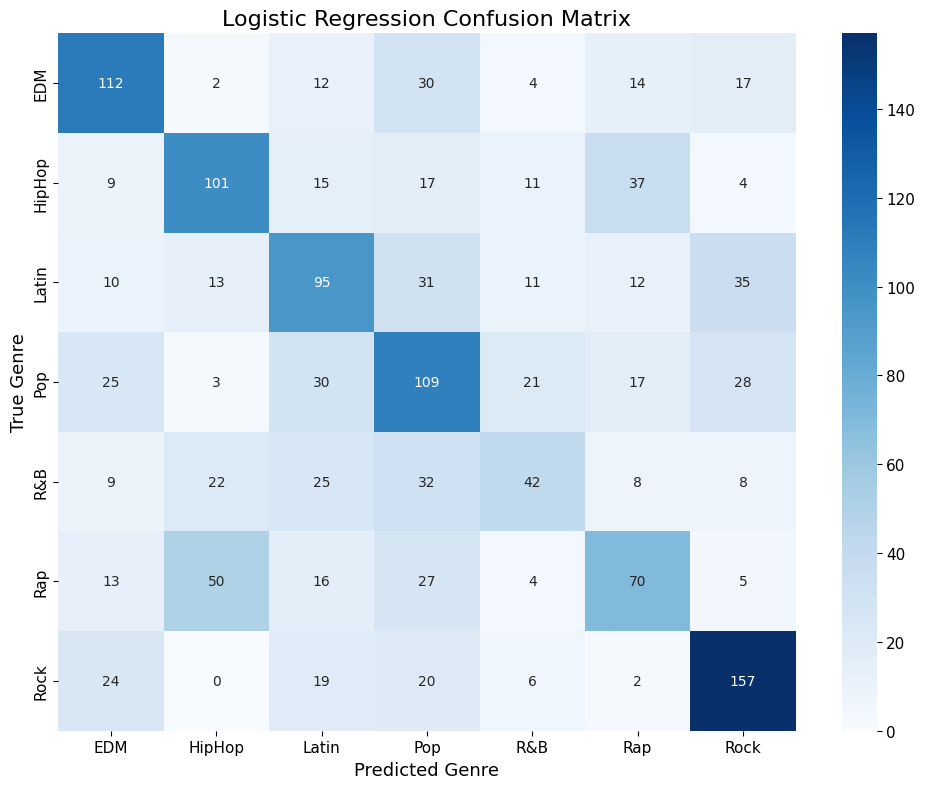

In [ ]:
# Logistic Regression using L1 regularization
model = LogisticRegression(
    l1_ratio=1,
    C=0.3,
    solver='saga',
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=genre_names
    )
)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=genre_names,
    yticklabels=genre_names
)

plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.title("Logistic Regression using L1's Confusion Matrix")

plt.tight_layout()
plt.show()


c:\Users\Luke Liu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Luke Liu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Train Accuracy: 0.531718778239653
Best Test Accuracy: 0.4985549132947977


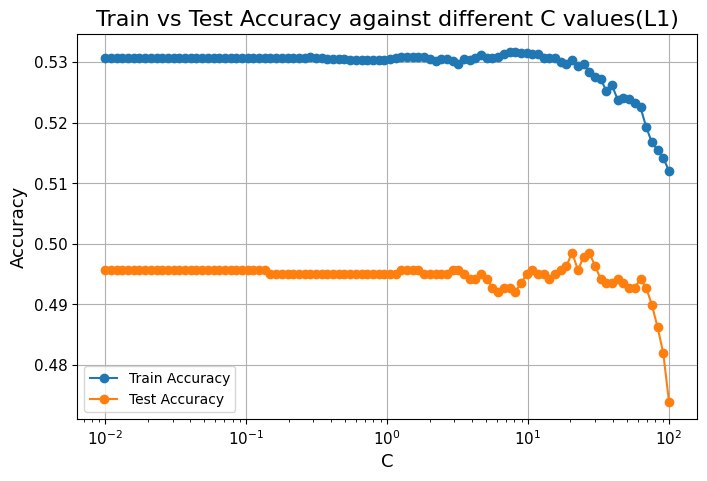

In [ ]:
lambda_values = np.logspace(-2, 2, 100)

train_accuracies = []
test_accuracies = []

for l in lambda_values:

    model = LogisticRegression(
        l1_ratio=1,
        C=1/l,
        solver='saga',
        max_iter=1000
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracies.append(
        accuracy_score(y_train, y_train_pred)
    )

    test_accuracies.append(
        accuracy_score(y_test, y_test_pred)
    )

print("Best Train Accuracy:", max(train_accuracies))
print("Best Test Accuracy:", max(test_accuracies))

plt.figure(figsize=(8, 5))

plt.plot(
    lambda_values,
    train_accuracies,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    lambda_values,
    test_accuracies,
    marker='o',
    label='Test Accuracy'
)

plt.grid(True)

plt.xscale('log')

plt.xlabel("λ")
plt.ylabel("Accuracy")

plt.title("Train vs Test Accuracy against different λ values(L1)")

plt.legend()

plt.show()

Best Train Accuracy: 0.5318995120187963
Best Test Accuracy: 0.4985549132947977


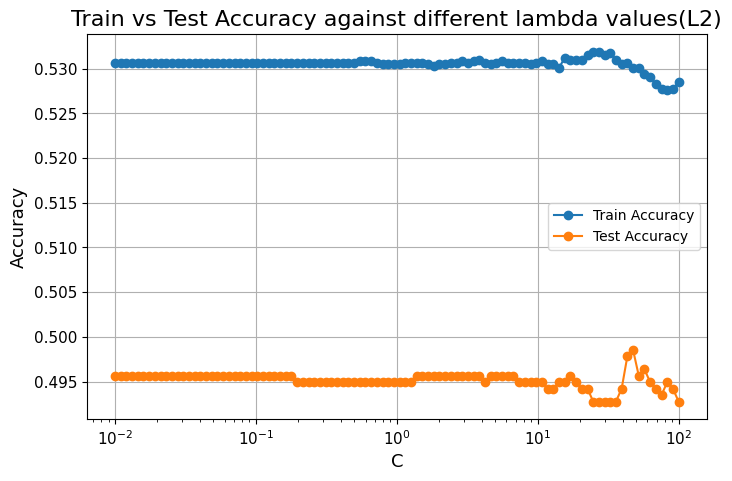

In [ ]:
lambda_values = np.logspace(-2, 2, 100)

train_accuracies = []
test_accuracies = []

for l in lambda_values:

    model = LogisticRegression(
        l1_ratio=0,
        C=1/l,
        solver='saga',
        max_iter=1000
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracies.append(
        accuracy_score(y_train, y_train_pred)
    )

    test_accuracies.append(
        accuracy_score(y_test, y_test_pred)
    )

print("Best Train Accuracy:", max(train_accuracies))
print("Best Test Accuracy:", max(test_accuracies))

plt.figure(figsize=(8, 5))

plt.plot(
    lambda_values,
    train_accuracies,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    lambda_values,
    test_accuracies,
    marker='o',
    label='Test Accuracy'
)

plt.grid(True)

plt.xscale('log')

plt.xlabel("λ")
plt.ylabel("Accuracy")

plt.title("Train vs Test Accuracy against different λ values(L2)")

plt.legend()

plt.show()

In [21]:
c_values = np.logspace(-2, 2, 10)
results = []

columns = list(X_train.columns)
for c in c_values:
    for k in range(1, len(columns) - 2):

        for i in range(len(columns) - k + 1):

            cols_to_drop = columns[i:i+k]

            X_train_drop = X_train.drop(columns=cols_to_drop)
            X_test_drop = X_test.drop(columns=cols_to_drop)

            model = LogisticRegression(
                C=c,
                solver='saga',
                max_iter=1000
            )

            model.fit(X_train_drop, y_train)

            y_pred = model.predict(X_test_drop)

            acc = accuracy_score(y_test, y_pred)

            results.append({
                'C': c,
                'k': k,
                'Dropped Features': cols_to_drop,
                'Accuracy': acc
            })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by='Accuracy',
        ascending=False
    )

print(results_df.head(20))

              C  k Dropped Features  Accuracy
3      0.010000  1            [key]  0.504335
81     0.077426  1            [key]  0.502890
198    1.668101  1            [key]  0.501445
42     0.027826  1            [key]  0.501445
315   35.938137  1            [key]  0.500723
237    4.641589  1            [key]  0.500723
276   12.915497  1            [key]  0.500723
354  100.000000  1            [key]  0.500723
159    0.599484  1            [key]  0.499277
120    0.215443  1            [key]  0.499277
6      0.010000  1   [acousticness]  0.497832
45     0.027826  1   [acousticness]  0.494942
47     0.027826  1          [tempo]  0.492775
240    4.641589  1   [acousticness]  0.489884
162    0.599484  1   [acousticness]  0.489884
86     0.077426  1          [tempo]  0.489884
201    1.668101  1   [acousticness]  0.489884
8      0.010000  1          [tempo]  0.489884
357  100.000000  1   [acousticness]  0.489884
279   12.915497  1   [acousticness]  0.489884
